# Energy Resolution Impact on Differential Cross Sections

This notebook visualises how TOF energy resolution broadens the differential
cross section at a given nominal energy. The top panel shows the elastic
cross-section curve inside the resolution window, coloured by energy. The
bottom panel overlays ~100 individual angular distributions sampled across
that window, together with EXFOR experimental data.

In [2]:
# ── Configuration ───────────────────────────────────────────────────────────
TARGET = 'Fe56'
TARGET_NAT = 'Fe'
MT = 2

NOMINAL_ENERGY_MEV = 1.40

FLIGHT_PATH_M = 27.037        # metres
DELTA_T_NS = 10.0              # nanoseconds
N_SIGMA = 3.0
N_ENERGY_SAMPLES = 100

ACE_PATH = '/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/ACE_samples/260560_81.02c'
EXFOR_DB_PATH = '/share_snc/snc/JuanMonleon/EXFOR/x4_iron_angular.db'
ENERGY_TOLERANCE = 0.02       # MeV

COLORMAP_NAME = 'coolwarm'
NUM_ANGULAR_POINTS = 200

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from matplotlib.colorbar import ColorbarBase

import kika
import kika.exfor as exfor
from kika.exfor import read_all_exfor
from kika.plotting import PlotBuilder
from kika.utils.energy_folding import compute_folded_differential_xs, EnergyFoldingConfig

exfor.configure(db_path=EXFOR_DB_PATH)

In [4]:
# ── Energy resolution (same formula as scripts/tof_parameters.py:202) ──────
NEUTRON_MASS_MEV = 939.565378
C_M_NS = 0.299792458  # speed of light in m/ns

velocity_m_ns = C_M_NS * np.sqrt(2.0 * NOMINAL_ENERGY_MEV / NEUTRON_MASS_MEV)
flight_time_ns = FLIGHT_PATH_M / velocity_m_ns
sigma_E_mev = NOMINAL_ENERGY_MEV * 2.0 * (DELTA_T_NS / flight_time_ns)

E_low = NOMINAL_ENERGY_MEV - N_SIGMA * sigma_E_mev
E_high = NOMINAL_ENERGY_MEV + N_SIGMA * sigma_E_mev
sample_energies = np.linspace(E_low, E_high, N_ENERGY_SAMPLES)

print(f'σ_E = {sigma_E_mev*1e3:.2f} keV')
print(f'Energy window: [{E_low:.4f}, {E_high:.4f}] MeV  ({N_SIGMA}σ)')

# ── Load ACE data ────────────────────────────────────────────────────────────
ace = kika.read_ace(ACE_PATH)

energies = np.asarray(ace.energies)
elastic_xs = np.asarray(ace.elastic_xs)

mask = (energies >= E_low) & (energies <= E_high)
e_window = energies[mask]
xs_window = elastic_xs[mask]

print(f'ACE grid points in window: {mask.sum()}')

# ── Load EXFOR ────────────────────────────────────────────────────────────────
fe56_experiments = read_all_exfor(target=TARGET, mt=MT, group_by_energy=False)
fe_nat_experiments = read_all_exfor(target=TARGET_NAT, mt=MT, group_by_energy=False)

all_experiments = []
for exp in fe56_experiments.values():
    en = exp.energies(unit='MeV')
    if np.any(np.abs(en - NOMINAL_ENERGY_MEV) <= ENERGY_TOLERANCE):
        all_experiments.append(exp)
for exp in fe_nat_experiments.values():
    en = exp.energies(unit='MeV')
    if np.any(np.abs(en - NOMINAL_ENERGY_MEV) <= ENERGY_TOLERANCE):
        all_experiments.append(exp)

print(f'EXFOR experiments near {NOMINAL_ENERGY_MEV} MeV: {len(all_experiments)}')

σ_E = 16.95 keV
Energy window: [1.3492, 1.4508] MeV  (3.0σ)
ACE grid points in window: 659
EXFOR experiments near 1.4 MeV: 3


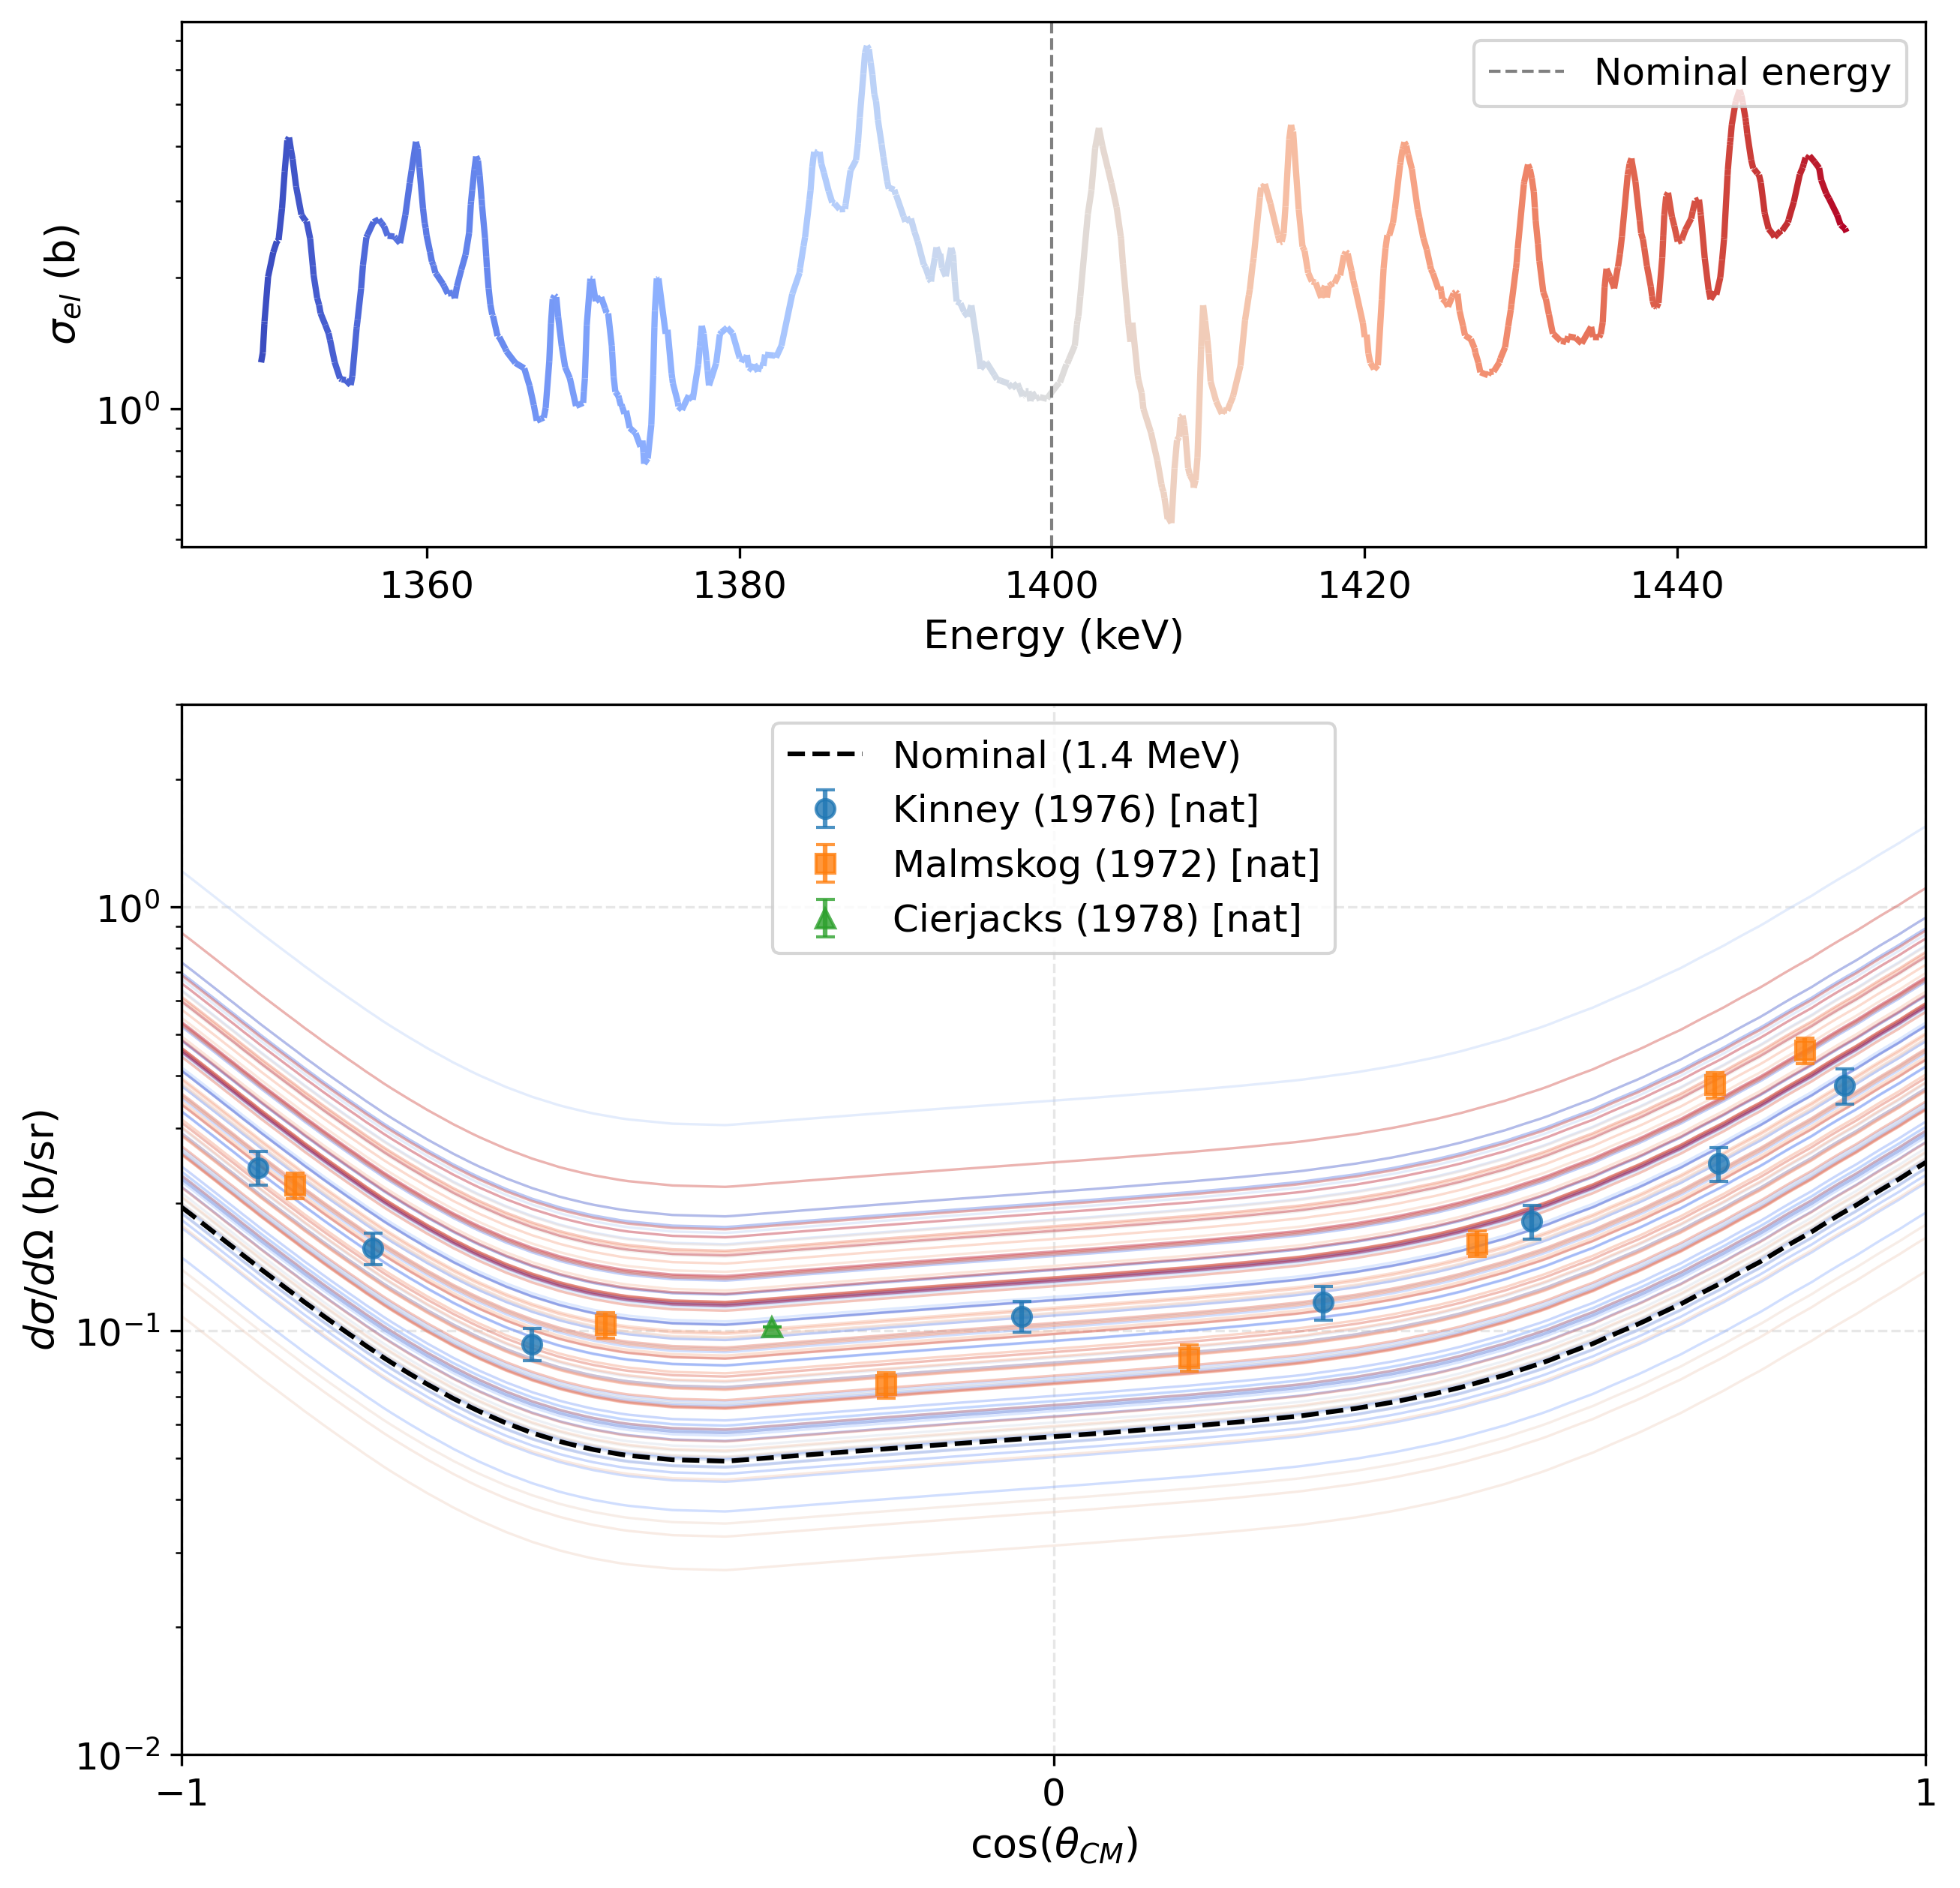

In [14]:
# ── Build figure ─────────────────────────────────────────────────────────────
from kika.ace.classes.angular_distribution.container import _get_xs_at_energy

cmap = plt.get_cmap(COLORMAP_NAME)
norm = mcolors.Normalize(vmin=E_low, vmax=E_high)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [1, 2]}, dpi=300
)

# ── Top panel: elastic XS coloured by energy ─────────────────────────────────
e_kev = e_window * 1e3
points = np.column_stack([e_kev, xs_window]).reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap=cmap, norm=mcolors.Normalize(vmin=E_low*1e3, vmax=E_high*1e3))
lc.set_array(e_kev[:-1])
lc.set_linewidth(2)
ax_top.add_collection(lc)
ax_top.autoscale()
ax_top.axvline(NOMINAL_ENERGY_MEV * 1e3, color='grey', ls='--', lw=1, label='Nominal energy')
ax_top.set_yscale('log')
ax_top.set_xlabel('Energy (keV)', fontsize=13)
ax_top.set_ylabel(r'$\sigma_{el}$ (b)', fontsize=13)
#ax_top.set_title(f'{TARGET}(n,el) cross section in resolution window')
ax_top.legend(loc='best', fontsize=12)
ax_top.tick_params(axis='both', which='both', labelsize=12)

# Colorbar for energy gradient
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
#cbar = fig.colorbar(sm, ax=ax_top, label='Energy (MeV)', pad=0.02)

# ── Bottom panel: fan of differential XS curves ──────────────────────────────
# Fix the angular PDF shape to the nominal energy; only vary the XS normalisation
nominal_df = ace.angular_distributions.to_dataframe(
    mt=MT,
    energy=NOMINAL_ENERGY_MEV,
    ace=ace,
    num_points=NUM_ANGULAR_POINTS,
    interpolate=True,
    normalize_to_xs=False,
    energy_folding=False,
)
nominal_cosine = nominal_df['cosine'].values
nominal_pdf = nominal_df['pdf'].values

for e_sample in sample_energies:
    xs_val = _get_xs_at_energy(ace, MT, e_sample)
    if xs_val is not None and xs_val > 0:
        dsigma_dOmega = nominal_pdf * xs_val / (2 * np.pi)
        ax_bot.plot(
            nominal_cosine, dsigma_dOmega,
            color=cmap(norm(e_sample)), alpha=0.4, lw=0.8,
        )

# Nominal-energy differential cross section
nominal_xs = _get_xs_at_energy(ace, MT, NOMINAL_ENERGY_MEV)
nominal_dsigma = nominal_pdf * nominal_xs / (2 * np.pi)
ax_bot.plot(
    nominal_cosine, nominal_dsigma,
    color='black', ls='--', lw=1.5, label=f'Nominal ({NOMINAL_ENERGY_MEV} MeV)',
)

# ── Energy-folded differential cross section (Gaussian kernel, 3σ) ───────────
folding_config = EnergyFoldingConfig(
    flight_path_m=FLIGHT_PATH_M,
    delta_t_ns=DELTA_T_NS,
    n_sigma=N_SIGMA,
    n_samples=N_ENERGY_SAMPLES,
)
mu_folded, dsigma_folded, fold_info = compute_folded_differential_xs(
    ace_data=ace,
    target_energy_mev=NOMINAL_ENERGY_MEV,
    mt=MT,
    config=folding_config,
    mode='both',
    num_mu_points=NUM_ANGULAR_POINTS,
)
#ax_bot.plot(
#    mu_folded, dsigma_folded,
#    color='green', ls='--', lw=2.0,
#    label=f'Energy-folded ({N_SIGMA:.0f}σ, σ$_E$={fold_info["sigma_E_kev"]:.1f} keV)',
#)

# ── Overlay EXFOR on bottom panel ────────────────────────────────────────────
markers = ['o', 's', '^', 'v', 'D', 'p', 'h', '*']
tab_colors = plt.cm.tab10.colors
for idx, exp in enumerate(all_experiments):
    plot_data = exp.to_plot_data(
        energy=NOMINAL_ENERGY_MEV,
        tolerance=ENERGY_TOLERANCE,
        frame='CM',
        angle_unit='cos',
        cross_section_unit='b/sr',
        uncertainty=True,
        include_natural_tag=True,
        marker=markers[idx % len(markers)],
        color=tab_colors[idx % len(tab_colors)],
        markersize=6,
        capsize=3,
        alpha=0.8,
    )
    if plot_data is not None:
        builder = PlotBuilder(ax=ax_bot)
        builder.add_data(plot_data)
        builder.build()

ax_bot.set_xlim(-1, 1)
ax_bot.set_ylim(0.01,3)
ax_bot.set_xlabel(r'$\cos(\theta_{CM})$', fontsize=13)
ax_bot.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=13)
#ax_bot.set_title(
#    f'{TARGET}(n,el) angular distributions across resolution window '
#    f'({NOMINAL_ENERGY_MEV} MeV ± {N_SIGMA}σ)'
#)
ax_bot.legend(loc='best', fontsize=12)
ax_bot.set_yscale('log')
ax_bot.tick_params(axis='both', which='both', labelsize=12)

plt.show()